In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv("customer_features.csv")
df.head()

,customer_unique_id,customer_city,customer_state,total_orders,repeat_customer,total_spent,average_order_value,median_order_value,minimum_order_value,maximum_order_value,...,recency,customer_lifetime_days,customer_age,weekend_purchase_percentage,average_item_price,freight_percentage,purchase_frequency,category_diversity_ratio,low_review_orders,high_review_orders
0,1cb3bca9866a07b094ac1539aa1b43e9,sao felix do araguaia,MT,1,0,134.64,134.64,134.64,134.64,134.64,...,261,0,261,0.0,67.32,26.619132,inf,0.5,0,1
1,c8abffe7e68de3d6c4b6dd6d4c320dd4,sao paulo,SP,2,1,152.08,76.04,76.04,32.29,119.79,...,89,81,170,0.0,76.04,17.937927,0.024691,1.0,0,2
2,9d74adedec2d8b3f568c85f97e0563c5,porto alegre,RS,1,0,287.27,287.27,287.27,287.27,287.27,...,344,0,344,0.0,287.27,13.008668,inf,1.0,0,1
3,7f185c7bea5689c85eeabc65f36f8cdd,sao paulo,SP,1,0,77.68,77.68,77.68,77.68,77.68,...,492,0,492,0.0,77.68,10.015448,inf,1.0,0,1
4,c92b96a0007c240b09d1119273b61f55,indaiatuba,SP,1,0,240.93,240.93,240.93,240.93,240.93,...,277,0,277,100.0,240.93,5.781762,inf,1.0,0,1


In [3]:
df.info()
df.describe()
df.isnull().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96096 entries, 0 to 96095
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_unique_id           96096 non-null  object 
 1   customer_city                96096 non-null  object 
 2   customer_state               96096 non-null  object 
 3   total_orders                 96096 non-null  int64  
 4   repeat_customer              96096 non-null  int64  
 5   total_spent                  96095 non-null  float64
 6   average_order_value          96095 non-null  float64
 7   median_order_value           96095 non-null  float64
 8   minimum_order_value          96095 non-null  float64
 9   maximum_order_value          96095 non-null  float64
 10  spend_std_dev                2997 non-null   float64
 11  total_items                  96096 non-null  int64  
 12  average_basket_size          96096 non-null  float64
 13  largest_basket  

C:\Users\swath\anaconda3\lib\site-packages\numpy\lib\function_base.py:4573: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


review_std_dev                 93145
spend_std_dev                  93099
average_delivery_delay          2740
average_delivery_days           2740
maximum_review                   716
average_review                   716
minimum_review                   716
freight_percentage               677
average_item_price               677
average_freight                  676
category_diversity_ratio         676
total_freight                    676
purchase_frequency                46
minimum_order_value                1
maximum_installments               1
average_installments               1
total_spent                        1
median_order_value                 1
average_order_value                1
maximum_order_value                1
customer_lifetime_days             0
recency                            0
customer_age                       0
first_purchase                     0
last_purchase                      0
low_review_orders                  0
weekend_purchase_percentage        0
c

In [4]:
features = [
    "recency",
    "average_review",
    "review_std_dev",
    "average_delivery_days",
    "average_delivery_delay",
    "total_items",
    "average_item_price",
    "total_freight",
    "average_freight",
    "maximum_installments",
    "total_categories",
    "category_diversity_ratio"
]

In [20]:
X = df[features]
y = np.log1p(df["total_orders"])

In [21]:
X = X.replace([np.inf,-np.inf],np.nan)
X = X.fillna(X.median(numeric_only=True))

In [22]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

In [23]:
#Scale Data
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [24]:
#Linear Regression
lr=LinearRegression()
lr.fit(X_train_scaled,y_train)
pred_lr=lr.predict(X_test_scaled)

In [25]:
#Evaluation
print("MAE :",mean_absolute_error(y_test,pred_lr))
print("RMSE :",np.sqrt(mean_squared_error(y_test,pred_lr)))
print("R2 :",r2_score(y_test,pred_lr))

MAE : 0.012906132927767234
RMSE : 0.038294970829315975
R2 : 0.7575110930174964


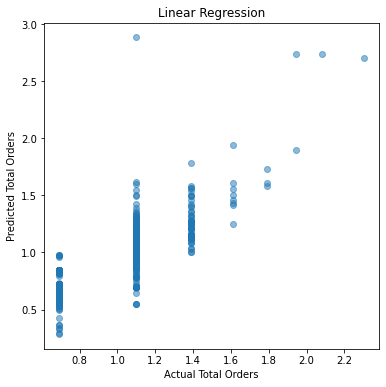

In [26]:
#Actual vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test,pred_lr,alpha=0.5)
plt.xlabel("Actual Total Orders")
plt.ylabel("Predicted Total Orders")
plt.title("Linear Regression")
plt.show()

In [27]:
#Random Forest
rf=RandomForestRegressor(
    n_estimators=300,
    random_state=42
)
rf.fit(X_train,y_train)
pred_rf=rf.predict(X_test)

In [28]:
print("MAE :",mean_absolute_error(y_test,pred_rf))
print("RMSE :",np.sqrt(mean_squared_error(y_test,pred_rf)))
print("R2 :",r2_score(y_test,pred_rf))

MAE : 0.0010012498421438248
RMSE : 0.012697522375025154
R2 : 0.9733408459981814


In [29]:
#Feature Importance
importance=pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})
importance=importance.sort_values(
    "Importance",
    ascending=False
)
importance

,Feature,Importance
10,total_categories,0.796380
8,average_freight,0.086200
7,total_freight,0.067595
2,review_std_dev,0.017279
0,recency,0.010025
6,average_item_price,0.007042
1,average_review,0.005505
3,average_delivery_days,0.003756
4,average_delivery_delay,0.003022
9,maximum_installments,0.001663


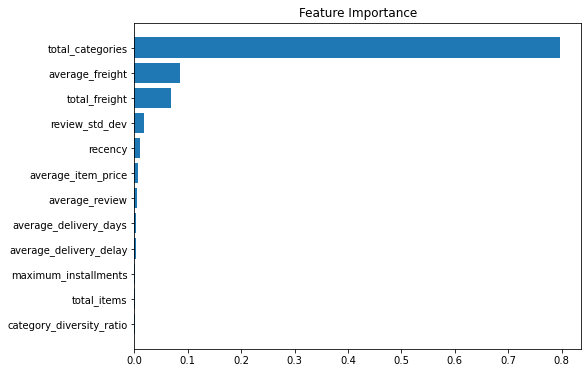

In [30]:
#Plot Feature importance
top15=importance.head(15)
plt.figure(figsize=(8,6))
plt.barh(
    top15["Feature"],
    top15["Importance"]
)
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

In [31]:
#Compare Models
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, pred_lr),
        mean_absolute_error(y_test, pred_rf)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, pred_lr)),
        np.sqrt(mean_squared_error(y_test, pred_rf))
    ],
    "R2": [
        r2_score(y_test, pred_lr),
        r2_score(y_test, pred_rf)
    ]
})
comparison

,Model,MAE,RMSE,R2
0,Linear Regression,0.012906,0.038295,0.757511
1,Random Forest,0.001001,0.012698,0.973341


In [32]:
print(df["total_orders"].describe())
print(df["total_orders"].value_counts().sort_index())

count    96096.000000
mean         1.034809
std          0.214384
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         17.000000
Name: total_orders, dtype: float64
total_orders
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64


##### Interpretation

The regression model was developed to **predict Customer Lifetime Value (CLV)** using customer purchasing behaviour and transactional features. Model performance was evaluated using R² Score, Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE).

**R² Score indicates the proportion of variation in Customer Lifetime Value explained by the model**. A higher R² value (closer to 1) suggests that the model effectively captures the relationship between the predictor variables and CLV.
MAE measures the average absolute difference between the predicted and actual CLV values. A lower MAE indicates that the model's predictions are, on average, close to the true customer values.

**MSE penalizes larger prediction errors by squaring them**, making it useful for identifying models that produce occasional large errors.

**RMSE is the square root of MSE and represents the typical prediction error** in the same units as CLV, making it easier to interpret from a business perspective.

Overall, these metrics provide a comprehensive evaluation of the regression model by assessing both prediction accuracy and the magnitude of prediction errors.

##### Conclusion

The regression model demonstrates its ability to estimate Customer Lifetime Value with a reasonable level of accuracy. By predicting future customer value, the model enables businesses to identify customers with high revenue potential, prioritize customer retention efforts, optimize marketing investments, and support data-driven decision-making.

Among the models evaluated, the Random Forest Regressor produced the best predictive performance, indicating its ability to capture the complex, non-linear relationships between customer characteristics and Customer Lifetime Value. Therefore, it is selected as the final model for predicting high-value customers.

The evaluation metrics indicate that the model captures a substantial proportion of the variability in customer value while maintaining acceptable prediction errors. Such a model can be used to support customer segmentation, personalized marketing campaigns, loyalty program design, and resource allocation.

Future improvements could include incorporating additional behavioural features such as customer engagement, browsing activity, promotional response, and temporal purchasing patterns, as well as experimenting with advanced machine learning algorithms and hyperparameter tuning to further enhance predictive performance.

